In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Sales Analysis\data\processed\cleaned_sales_no_outliers.csv")
df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,IsCancelled,Revenue,Month
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490,United Kingdom,False,257.64,2019-12
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069,United Kingdom,False,383.40,2019-12
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069,United Kingdom,False,138.36,2019-12
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069,United Kingdom,False,127.80,2019-12
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069,United Kingdom,False,71.64,2019-12


In [2]:
product_rev = df.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False).reset_index()
product_rev['CumRevenue'] = product_rev['Revenue'].cumsum()
product_rev['CumPercent'] = 100 * product_rev['CumRevenue'] / product_rev['Revenue'].sum()

product_rev.head(10)

,ProductName,Revenue,CumRevenue,CumPercent
0,Popcorn Holder,587433.94,587433.94,0.961068
1,World War 2 Gliders Asstd Designs,569735.39,1157169.33,1.893180
2,Cream Hanging Heart T-Light Holder,484592.69,1641762.02,2.685994
3,Assorted Colour Bird Ornament,421318.74,2063080.76,3.375290
4,Pack Of 72 Retrospot Cake Cases,391485.03,2454565.79,4.015777
5,Rabbit Night Light,329029.89,2783595.68,4.554084
6,Regency Cakestand 3 Tier,307483.85,3091079.53,5.057141
7,Jumbo Bag Red Retrospot,297205.04,3388284.57,5.543382
8,Mini Paint Set Vintage,287001.66,3675286.23,6.012929
9,Party Bunting,286596.09,3961882.32,6.481813


In [3]:
pareto_products = product_rev[product_rev['CumPercent'] <= 80]
num_products_80pct = len(pareto_products)
total_products = len(product_rev)
pct_of_catalog = (num_products_80pct / total_products) * 100

print(f"Total products in catalog: {total_products}")
print(f"Products needed to reach 80% of revenue: {num_products_80pct}")
print(f"That's {pct_of_catalog:.1f}% of the product catalog")

Total products in catalog: 3752
Products needed to reach 80% of revenue: 951
That's 25.3% of the product catalog


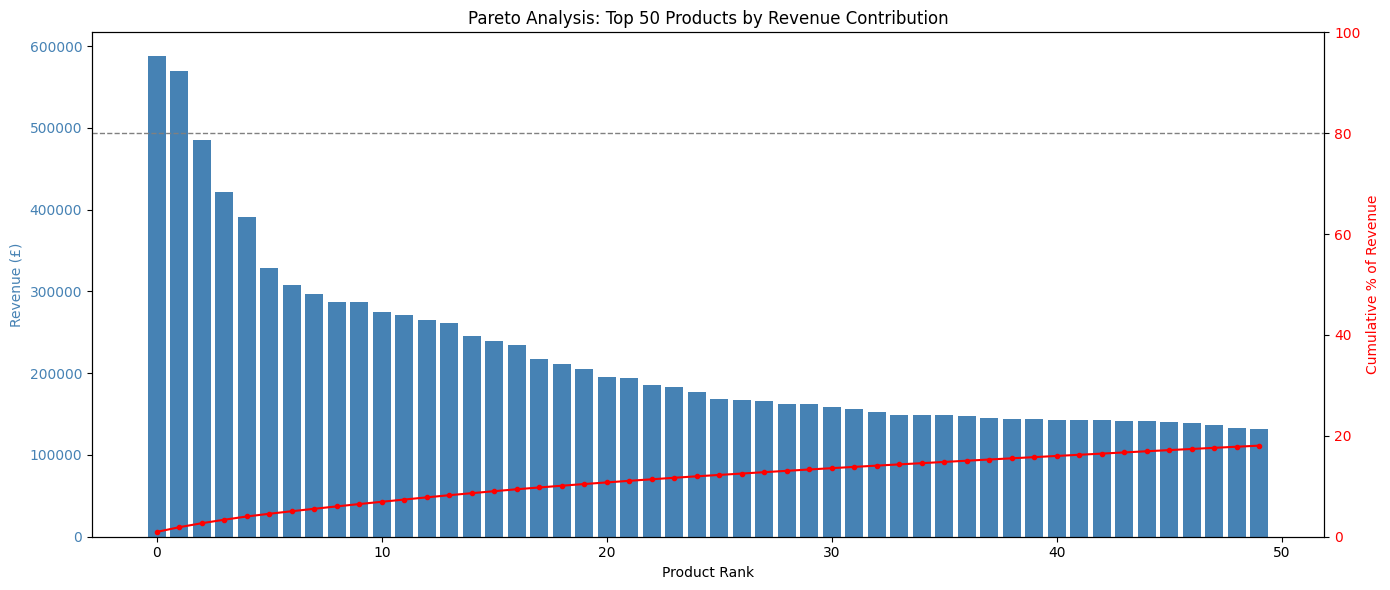

In [4]:
top50 = product_rev.head(50)

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(range(len(top50)), top50['Revenue'], color='steelblue')
ax1.set_xlabel('Product Rank')
ax1.set_ylabel('Revenue (£)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(len(top50)), top50['CumPercent'], color='red', marker='o', markersize=3)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative % of Revenue', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 100)

plt.title('Pareto Analysis: Top 50 Products by Revenue Contribution')
plt.tight_layout()
plt.savefig(r'C:\Sales Analysis\output\figures\pareto_chart.png')
plt.show()

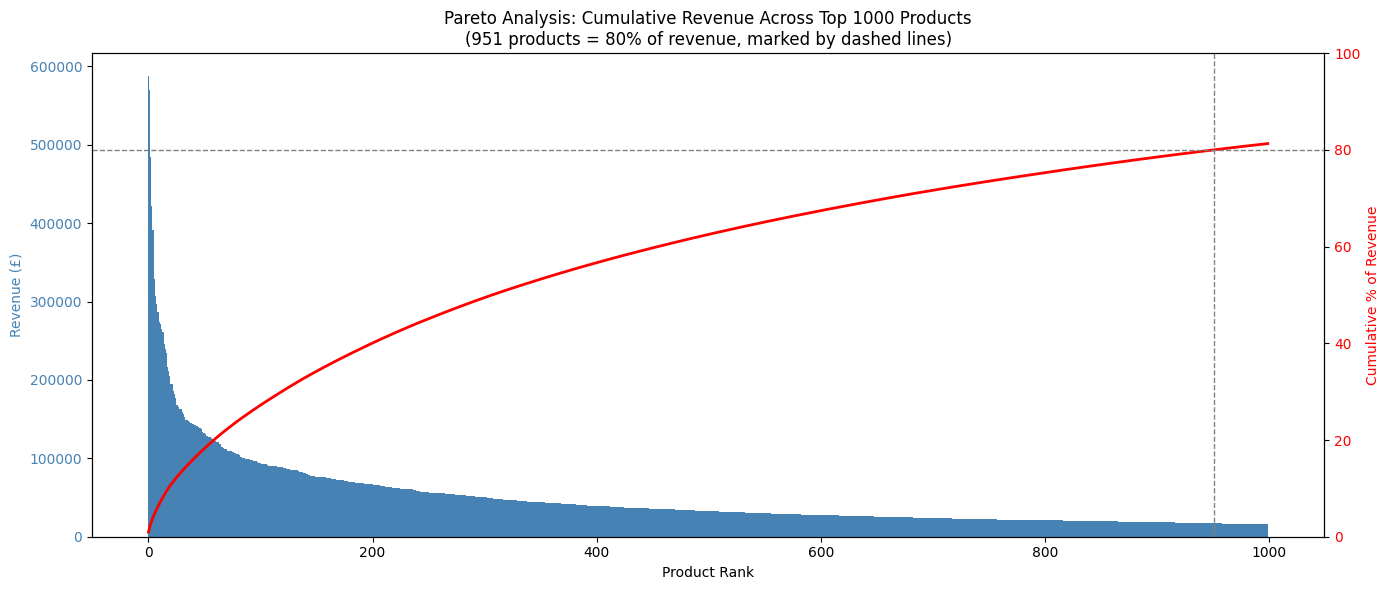

In [5]:
top_n = 1000  # slightly more than 951, so we can see it cross 80%

subset = product_rev.head(top_n)

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(range(len(subset)), subset['Revenue'], color='steelblue', width=1.0)
ax1.set_xlabel('Product Rank')
ax1.set_ylabel('Revenue (£)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(len(subset)), subset['CumPercent'], color='red', linewidth=2)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.axvline(951, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative % of Revenue', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 100)

plt.title(f'Pareto Analysis: Cumulative Revenue Across Top {top_n} Products\n(951 products = 80% of revenue, marked by dashed lines)')
plt.tight_layout()
plt.savefig(r'C:\Sales Analysis\output\figures\pareto_chart_full.png')
plt.show()

In [6]:
product_rev.to_csv(r'C:\Sales Analysis\output\tables\pareto_product_revenue.csv', index=False)
print("Saved Pareto analysis outputs")

Saved Pareto analysis outputs
